# 2D self-consistent Thomas–Fermi solver with half-covered top-gate image charges and magnetic-field sweep

This notebook is the 2D analogue of `gpt_TF_confinement_B_sweep_fixed_dist.ipynb`, modified so that **top-gate image charges are included only for source charges in the first half of the system along the x direction**.

Main features:

- grid is `(x,y)` on a rectangular Hall-bar domain;
- densities, potentials, filling factor, and compressibility are 2D arrays;
- Hartree and donor potentials use **open-boundary FFT convolution**;
- electron-electron Hartree interaction uses a partial-image kernel:
  \[
  U_H(\mathbf r)=\kappa_0 K_{ee}^{\rm direct}*n-\kappa_0 K_{ee}^{\rm img}*(m_x n),
  \]
  where \(m_x=1\) on the first half of the system, and \(0\) elsewhere;
- donor-electron attraction uses the same partial-image logic, but donor image charges use an effective top-gate distance that is 50 nm larger.

All lengths are in nm, energies in meV, and densities in nm\(^{-2}\).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, replace
from pathlib import Path
import json, dataclasses, shutil

from scipy.special import erf
from scipy.optimize import brentq
from scipy.signal import fftconvolve
from scipy.ndimage import gaussian_filter
from matplotlib.animation import FuncAnimation, FFMpegWriter, PillowWriter
from IPython.display import HTML, display

plt.rcParams.update({"font.size": 12})
import sys
from time import time

from modules.simulation_io import (
    prepare_simulation,
    print_simulation_info,
    params_to_json_dict,
    json_safe_value,
)
from modules.grid_kernel_confinement_io import make_kernel_and_background_2d
from modules.hartree_io import (
    solve_self_consistent_2d,
    average_density_2d,
)

In [2]:
@dataclass
class Params2D:
    # full rectangular Hall bar dimensions in nm
    Lx: float = 6000.0
    Ly: float = 2000.0
    Nx: int = 901
    Ny: int = 601

    use_elliptic_mask: bool = False

    # material / electrostatics
    eps_r: float = 13.0
    n_donor: float = 2.0e-3     #I'm using a normalization for which 
    n_target: float = 1.0e-3
    n_surf: float = 1.0e-3 
    
    
    dS: float = 200    #nm
    donor_margin_nm: float = 0.0
    donor_smooth_nm: float = 0.0
    
    donor_disorder_rms: float = 1.5e-3 * 1e-6      # nm^-2
    donor_disorder_sigma_nm: float = 20.0 # correlation length [nm]
    donor_disorder_seed: int = 1

    # top-gate distance in nm. Use None for bare Coulomb.
    dist_fixed: float = 2e2 #| None = 200.0

    # Partial top-gate image configuration.
    # Images are included only for source charges with x <= x_gate_edge_nm.
    use_partial_top_gate: bool = True
    x_gate_edge_nm: float = 4000.0 #| None = 0.0

    # Donor image charges use a top-gate distance dist_fixed + donor_extra_dist_nm.
    donor_extra_dist_nm: float = -90.0

    # magnetic field / LLs
    B: float = 1.5
    g_spin: float = 0.0
    n_LL: int = 6
    gamma_rel: float = .02
    use_B_scaling: bool = True

    # self-consistency
    max_iter: int = 40000
    mix: float = 0.003
    tol: float = 7e-9
    smooth_sigma_nm: float = 0.0

    # Coulomb regularization at r=0; if None, use area-equivalent disk radius
    diagonal_cutoff_nm: float | None = None

    @property
    def kappa0(self):
        # e^2/(4*pi*eps0*eps_r) in meV nm
        return 1440.0 / self.eps_r

    @property
    def hbar_omega_c(self):
        return 1.76 * self.B

    @property
    def lB(self):
        return 25.658 / np.sqrt(self.B)

    @property
    def Gamma(self):
        if self.use_B_scaling:
            return self.gamma_rel * self.hbar_omega_c * np.sqrt(10.0 / self.B)
        return self.gamma_rel * self.hbar_omega_c

p = Params2D()

## Optional resume from the latest saved simulation

Set `USE_LATEST_SAVED_SIMULATION = True` to load the most recent saved run from `RESULTS_DIR`. The notebook will restore the saved parameters, then apply any entries in `PARAMETER_OVERRIDES` before starting the new self-consistent calculation. If the saved potential has the same grid shape, it is used as `U_initial` to continue/converge faster.

In [3]:
# --- Resume controls ---------------------------------------------------------

USE_LATEST_SAVED_SIMULATION = False

RESULTS_DIR = Path("data_singlerun")

#PARAMETER_OVERRIDES = {"x_gate_edge_nm":300}
PARAMETER_OVERRIDES = {}

USE_SAVED_U_AS_INITIAL_GUESS = True


(
    p,
    U_INITIAL_FROM_SAVED_RUN,
    RESUMED_RUN_DIR,
    RESUMED_METADATA,
    RESUMED_DATA,
) = prepare_simulation(
    p,
    results_dir=RESULTS_DIR,
    parameter_overrides=PARAMETER_OVERRIDES,
    use_latest_saved_simulation=USE_LATEST_SAVED_SIMULATION,
    use_saved_U_as_initial_guess=USE_SAVED_U_AS_INITIAL_GUESS,
)

print_simulation_info(p)

Active parameters:
Params2D(Lx=6000.0, Ly=2000.0, Nx=901, Ny=601, use_elliptic_mask=False, eps_r=13.0, n_donor=0.002, n_target=0.001, n_surf=0.001, dS=200, donor_margin_nm=0.0, donor_smooth_nm=0.0, donor_disorder_rms=1.5e-09, donor_disorder_sigma_nm=20.0, donor_disorder_seed=1, dist_fixed=200.0, use_partial_top_gate=True, x_gate_edge_nm=4000.0, donor_extra_dist_nm=-90.0, B=1.5, g_spin=0.0, n_LL=6, gamma_rel=0.02, use_B_scaling=True, max_iter=40000, mix=0.003, tol=7e-09, smooth_sigma_nm=0.0, diagonal_cutoff_nm=None)
dx, dy = 6.667 nm, 3.333 nm
grid points = 541501
lB = 20.950 nm, hbar omega_c = 2.640 meV, Gamma = 0.1363 meV
Expected average filling = 2.7576


## 2D grid, donor profile, and Coulomb kernel

In [4]:
# --- Grid, Coulomb kernels, and external confinement -------------------------
bg = make_kernel_and_background_2d(
    p,
    dist=p.dist_fixed,
)
x = bg.x
y = bg.y
X = bg.X
Y = bg.Y
dx = bg.dx
dy = bg.dy

xS = bg.xS
yS = bg.yS
XS = bg.XS
YS = bg.YS

mask = bg.mask

K = bg.K
nD = bg.nD
nS = bg.nS
U_ext = bg.U_ext

top_gate_source_mask = bg.top_gate_source_mask
hartree_from_density = bg.hartree_from_density

K_ee_direct = bg.K_ee_direct
K_ee_image = bg.K_ee_image
K_donor_direct = bg.K_donor_direct
K_donor_image = bg.K_donor_image

Surface crop: 30 930 60 660
grid: 901 961 U_surf_mask: (601, 901) dx,dy: 6.666666666666515 3.3333333333333712


In [5]:
print(dx, dy, p.lB, p.dist_fixed, p.donor_extra_dist_nm, max(xS))


6.666666666666515 3.3333333333333712 20.949669273443597 200.0 -90.0 3199.9999999998545


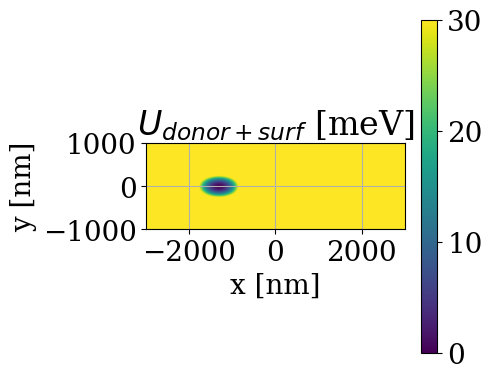

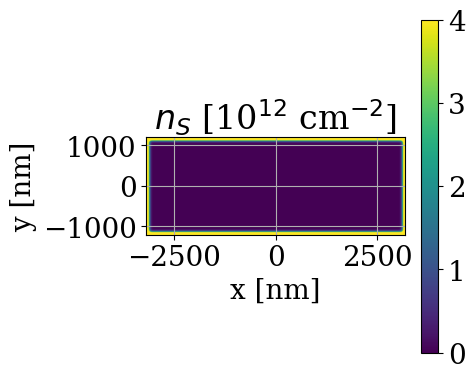

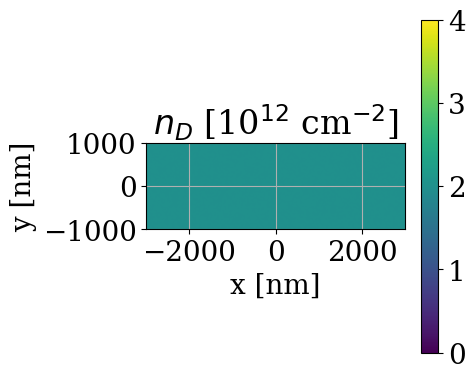

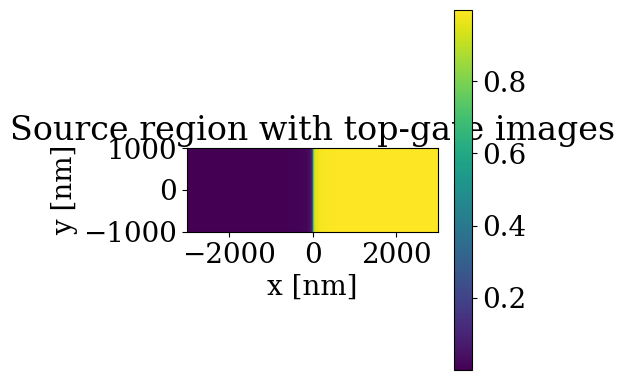

In [6]:

# Font configuration
font = {
    'family': 'serif',
    'color': 'black',
    'weight': 'normal',
    'size': 20,
}

plt.rcParams['font.family'] = font['family']
plt.rcParams['font.size'] = font['size']
plt.rcParams['axes.labelsize'] = font['size']
plt.rcParams['xtick.labelsize'] = font['size']
plt.rcParams['ytick.labelsize'] = font['size']

fig1, ax = plt.subplots(figsize=(5.2, 4.2))

im = ax.imshow(
    U_ext - np.amin(U_ext),
    origin="lower",
    extent=[
        x.min(),
        x.max(),
        y.min(),
        y.max(),
    ],
    aspect="equal",
    vmin=0,
    vmax=30,
)

ax.set_xlabel("x [nm]")
ax.set_ylabel("y [nm]")
ax.set_title(r"$U_{donor+surf}$ [meV]")
ax.grid()

fig1.colorbar(im, ax=ax)
fig1.tight_layout()


figS, axS = plt.subplots(figsize=(5.2, 4.2))

imS = axS.imshow(
    nS * 1e3,
    origin="lower",
    extent=[
        xS.min(),
        xS.max(),
        yS.min(),
        yS.max(),
    ],
    aspect="equal",
    vmin=0,
    vmax=4,
)

axS.set_xlabel("x [nm]")
axS.set_ylabel("y [nm]")
axS.set_title(
    r"$n_S$ [10$^{12}$ cm$^{-2}$]"
)
axS.grid()

figS.colorbar(imS, ax=axS)
figS.tight_layout()

figD, axD = plt.subplots(figsize=(5.2, 4.2))
imD = axD.imshow(
    nD * 1e3,
    origin="lower",
    extent=[
        x.min(),
        x.max(),
        y.min(),
        y.max(),
    ],
    aspect="equal",
    vmin=0,
    vmax=4,
)
axD.set_xlabel("x [nm]")
axD.set_ylabel("y [nm]")
axD.set_title(
    r"$n_D$ [10$^{12}$ cm$^{-2}$]"
)
axD.grid()
figD.colorbar(imD, ax=axD)
figD.tight_layout()


fig2, ax = plt.subplots(figsize=(5.2, 4.2))

im = ax.imshow(
    top_gate_source_mask,
    origin="lower",
    extent=[
        x.min(),
        x.max(),
        y.min(),
        y.max(),
    ],
    aspect="equal",
)

ax.set_xlabel("x [nm]")
ax.set_ylabel("y [nm]")
ax.set_title(
    "Source region with top-gate images"
)

fig2.colorbar(im, ax=ax)
fig2.tight_layout()

## Self-consistent loop

In [7]:
# --- Self-consistent Hartree calculation ------------------------------------
res = solve_self_consistent_2d(
    p,
    dist=p.dist_fixed,
    U_initial=U_INITIAL_FROM_SAVED_RUN,
    background=bg,
    verbose=True,
)

print("history tail:")
print(res["history"][-5:])

print(
    "average density:",
    average_density_2d(
        res["n"],
        res["mask"],
        res["dx"],
        res["dy"],
    ),
    "target:",
    p.n_target,
)

print(
    "center filling:",
    res["nu"][
        p.Ny // 2,
        p.Nx // 2,
    ],
)

it=   0, mu=560.182, n_avg=0.001, dn=1.352e-05
it=  25, mu=552.622, n_avg=0.001, dn=1.578e-05
it=  50, mu=543.04, n_avg=0.001, dn=1.797e-05
it=  75, mu=532.076, n_avg=0.001, dn=2.112e-05
it= 100, mu=520.255, n_avg=0.001, dn=2.468e-05
it= 125, mu=507.377, n_avg=0.001, dn=2.816e-05
it= 150, mu=493.141, n_avg=0.001, dn=2.933e-05
it= 175, mu=477.008, n_avg=0.001, dn=2.798e-05
it= 200, mu=459.153, n_avg=0.001, dn=2.512e-05
it= 225, mu=440.273, n_avg=0.001, dn=2.206e-05
it= 250, mu=420.885, n_avg=0.001, dn=1.966e-05
it= 275, mu=401.271, n_avg=0.001, dn=1.786e-05
it= 300, mu=381.687, n_avg=0.001, dn=1.681e-05
it= 325, mu=362.285, n_avg=0.001, dn=1.662e-05
it= 350, mu=343.151, n_avg=0.001, dn=1.664e-05
it= 375, mu=324.61, n_avg=0.001, dn=1.525e-05
it= 400, mu=306.717, n_avg=0.001, dn=1.311e-05
it= 425, mu=289.527, n_avg=0.001, dn=5.739e-06
it= 450, mu=272.979, n_avg=0.001, dn=4.647e-06
it= 475, mu=257.129, n_avg=0.001, dn=3.578e-06
it= 500, mu=241.978, n_avg=0.001, dn=2.963e-06
it= 525, mu=227

## 2D diagnostics

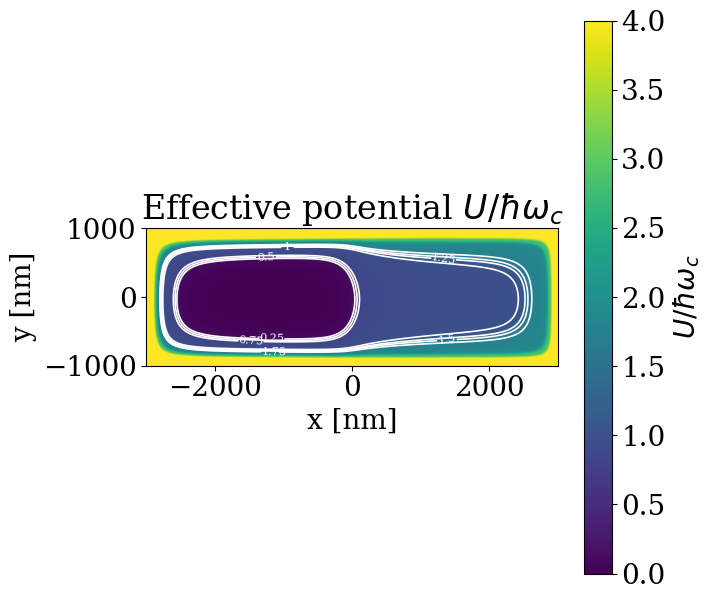

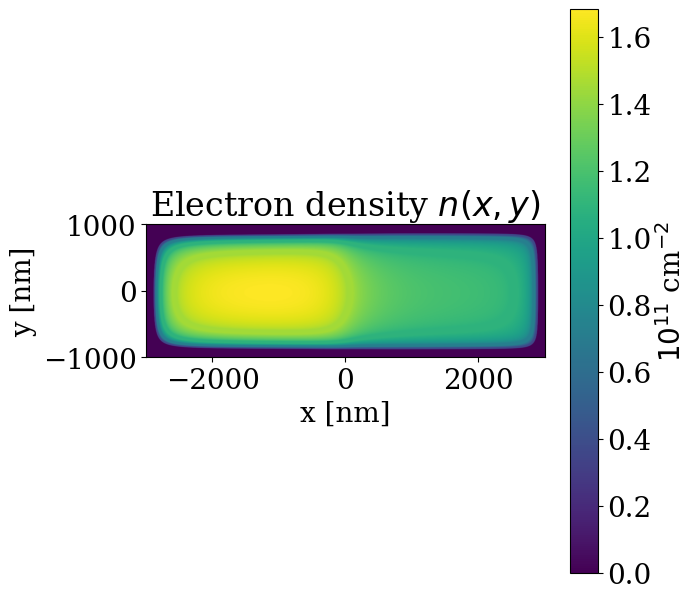

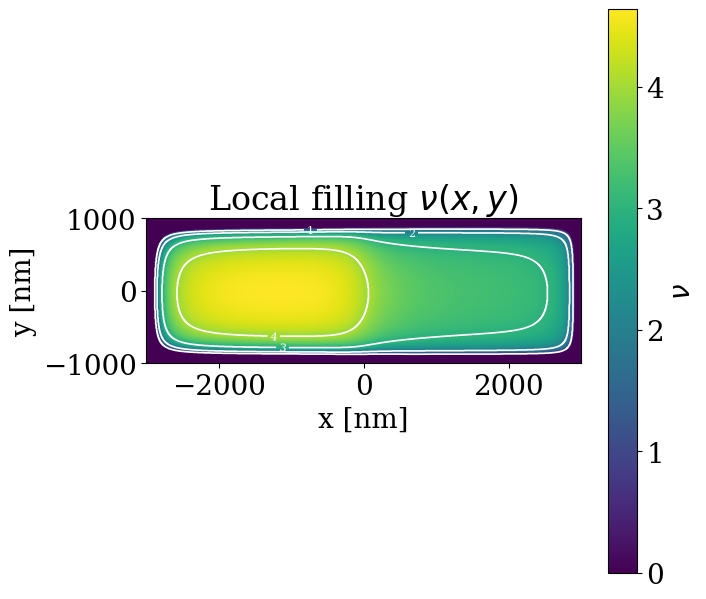

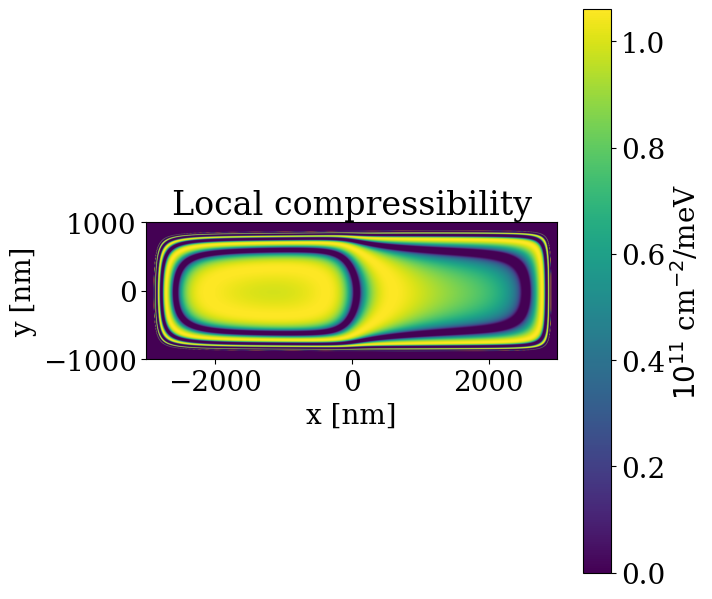

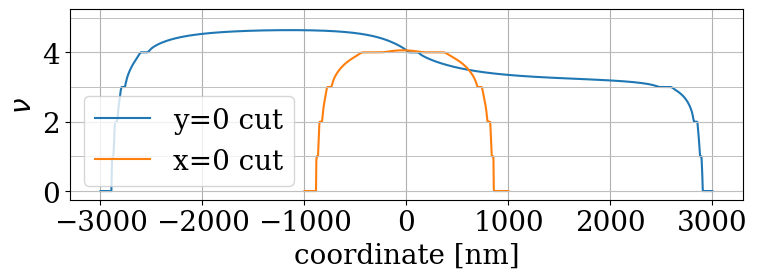

In [8]:

# Font configuration
font = {
    'family': 'serif',
    'color': 'black',
    'weight': 'normal',
    'size': 20,
}

plt.rcParams['font.family'] = font['family']
plt.rcParams['font.size'] = font['size']
plt.rcParams['axes.labelsize'] = font['size']
plt.rcParams['xtick.labelsize'] = font['size']
plt.rcParams['ytick.labelsize'] = font['size']

def plot_map(arr, x, y, title, label, vmin=None, vmax=None,
             contour_levels=None, contour_kwargs=None, clabel=True):

    fig, ax = plt.subplots(figsize=(7.4, 6.4))

    im = ax.imshow(
        arr,
        origin="lower",
        extent=[x.min(), x.max(), y.min(), y.max()],
        aspect="equal",
        vmin=vmin,
        vmax=vmax,
    )

    if contour_levels is not None and len(contour_levels) > 0:

        X, Y = np.meshgrid(x, y, indexing="xy")

        kw = dict(colors="white", linewidths=1.1)

        if contour_kwargs is not None:
            kw.update(contour_kwargs)

        cs = ax.contour(
            X, Y, arr,
            levels=contour_levels,
            **kw
        )

        if clabel:
            ax.clabel(
                cs,
                inline=True,
                fontsize=8,
                fmt="%g"
            )

    ax.set_xlabel("x [nm]")
    ax.set_ylabel("y [nm]")
    ax.set_title(title)

    cb = fig.colorbar(im, ax=ax)
    cb.set_label(label)

    fig.tight_layout()

    return fig, ax, im


def plot_solution_2d(
    res,
    p: Params2D,
    U_vmin=0,
    U_vmax=4,
):

    x, y = res["x"], res["y"]
    U = res["U"]
    n = res["n"]
    nu = res["nu"]
    comp = res["compressibility"]

    U_scaled = (U - np.nanmin(U)) / p.hbar_omega_c
    integer_levels = np.arange(
        0,
        2,
        .25,
    )
    fig3, ax3, im3 = plot_map(
        U_scaled,
        x,
        y,
        r"Effective potential $U/\hbar\omega_c$",
        r"$U/\hbar\omega_c$",
        vmin=U_vmin,
        vmax=U_vmax,
        contour_levels=integer_levels,
        contour_kwargs=dict(
            colors="white",
            linewidths=1.2,
        ),
        clabel=True,
    )

    fig4, ax4, im4 = plot_map(
        n / 1e-3,
        x,
        y,
        r"Electron density $n(x,y)$",
        r"$10^{11}$ cm$^{-2}$",
    )

    nu_min = np.nanmin(nu)
    nu_max = np.nanmax(nu)

    integer_levels = np.arange(
        max(1, int(np.ceil(nu_min))),
        int(np.floor(nu_max)) + 1,
        1,
    )

    fig5, ax5, im5 = plot_map(
        nu,
        x,
        y,
        r"Local filling $\nu(x,y)$",
        r"$\nu$",
        contour_levels=integer_levels,
        contour_kwargs=dict(
            colors="white",
            linewidths=1.2,
        ),
        clabel=True,
    )
    

    fig6, ax6, im6 = plot_map(
        comp / 1e-3,
        x,
        y,
        r"Local compressibility",
        r"$10^{11}$ cm$^{-2}$/meV",
    )
    

    iy = len(y) // 2
    ix = len(x) // 2

    fig, ax = plt.subplots(figsize=(8, 3.2))

    ax.plot(x, nu[iy, :], label="y=0 cut")
    ax.plot(y, nu[:, ix], label="x=0 cut")

    for m in range(0, int(np.nanmax(nu)) + 2):
        ax.axhline(m, color="0.75", lw=0.7)

    ax.set_xlabel("coordinate [nm]")
    ax.set_ylabel(r"$\nu$")
    ax.grid(True)
    ax.legend()

    fig.tight_layout()
    
    return fig3, fig4, fig5, fig6, fig


# examples:
fig3, fig4, fig5, fig6, fig7 = plot_solution_2d(res, p)

# zoom on potential
# plot_solution_2d(res, p, U_vmin=0.95, U_vmax=1.05)

15.928141716966424


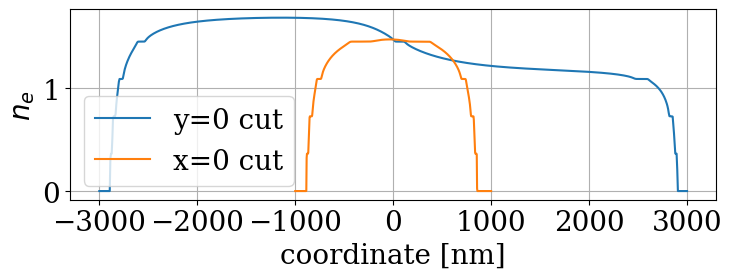

In [9]:
iy = len(y) // 2
ix = len(x) // 2

nxx = np.argmin(np.abs(x-600))

fig, ax = plt.subplots(figsize=(8, 3.2))
n_e_res = res["n"]*1e3
ax.plot(x, n_e_res[iy, :], label="y=0 cut")
ax.plot(y, n_e_res[:, ix], label="x=0 cut")

ax.set_xlabel("coordinate [nm]")
ax.set_ylabel(r"$n_e$")
ax.grid(True)
ax.legend()

fig.tight_layout()
print( (n_e_res[iy, ix]- n_e_res[iy, nxx])/n_e_res[iy, nxx]*100 )

In [10]:
print(n_e_res[iy, ix])
print(n_e_res[iy, ix]/n_e_res[iy, int(ix/2)]-1)

1.4711895724455513
-0.12280702862696236


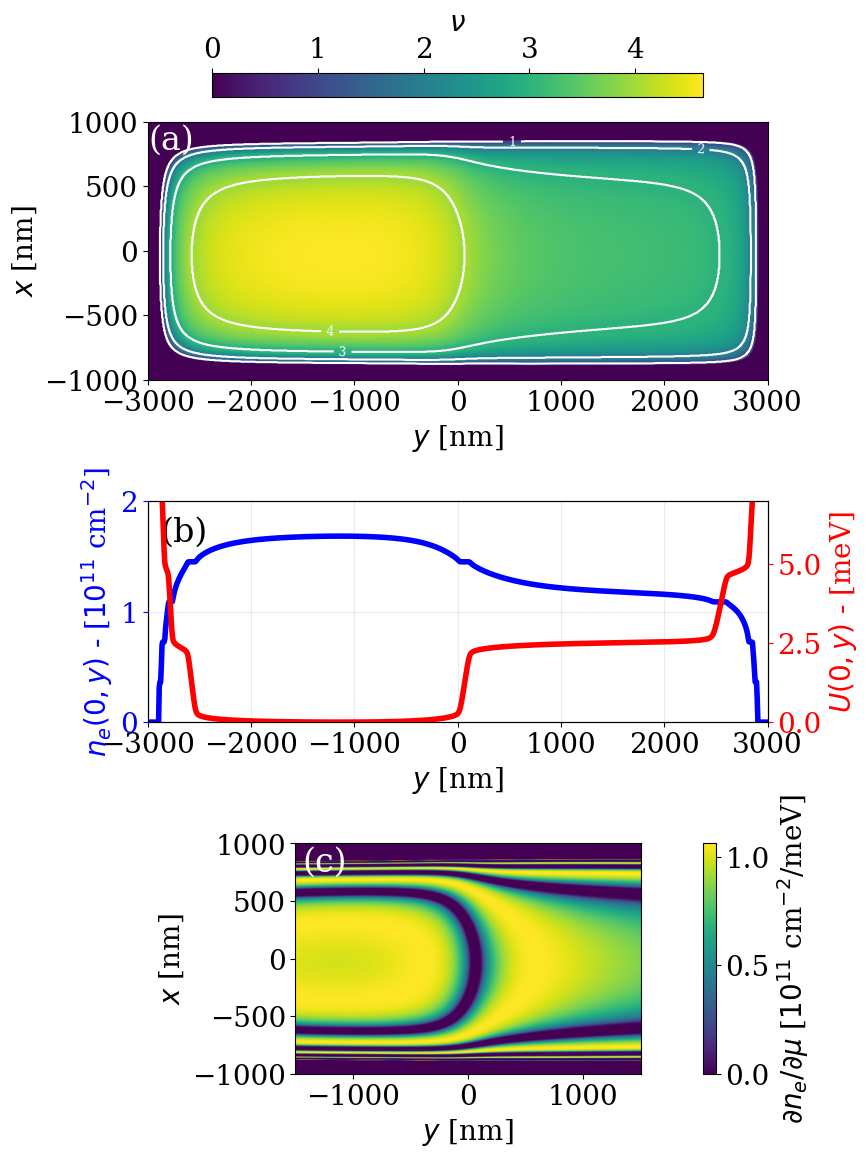

In [11]:
# ============================================================
# Combined 3-panel figure
#
# Numerical coordinates are unchanged.
# Only the displayed labels are swapped:
#   numerical x -> label "y"
#   numerical y -> label "x"
#
# (a) Local filling factor + integer isolines
# (b) Central cut: n_e(x=0,y) + U(x=0,y)
# (c) Compressibility, restricted to numerical x = ±1000 nm
#     and displayed centered at approximately half width
# ============================================================
font = {
    'family': 'serif',
    'color': 'black',
    'weight': 'normal',
    'size': 20,
}

plt.rcParams['font.family'] = font['family']
plt.rcParams['font.size'] = font['size']
plt.rcParams['axes.labelsize'] = font['size']
plt.rcParams['xtick.labelsize'] = font['size']
plt.rcParams['ytick.labelsize'] = font['size']
# ------------------------------------------------------------
# Data
# ------------------------------------------------------------
x = res["x"]
y = res["y"]
U = res["U"]
n = res["n"]
nu = res["nu"]
comp = res["compressibility"]

# Numerical y = 0 cut
# After relabeling, this corresponds to x = 0
iy = np.argmin(np.abs(y))


# ------------------------------------------------------------
# Figure layout
# ------------------------------------------------------------
fig = plt.figure(figsize=(8.0, 13))

gs = fig.add_gridspec(
    3, 12,
    height_ratios=[1.0, 0.72, .75],
    hspace=0.48,
    wspace=0.0,
)

# Panels (a) and (b): full width
ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, :])

# Panel (c): centered, approximately half width
# Bottom panel region, centered
gs_c = gs[2, 2:11].subgridspec(
    1, 2,
    width_ratios=[1.2, 0.035],
    wspace=0.08,
)

ax3 = fig.add_subplot(gs_c[0, 0])
cax3 = fig.add_subplot(gs_c[0, 1])


# ============================================================
# (a) Local filling factor
# ============================================================

im1 = ax1.imshow(
    nu,
    origin="lower",
    extent=[x.min(), x.max(), y.min(), y.max()],
    aspect="auto",
)

# Integer filling contours
nu_min = np.nanmin(nu)
nu_max = np.nanmax(nu)

integer_levels = np.arange(
    max(1, int(np.ceil(nu_min))),
    int(np.floor(nu_max)) + 1,
    1,
)

X, Y = np.meshgrid(x, y, indexing="xy")

cs1 = ax1.contour(
    X,
    Y,
    nu,
    levels=integer_levels,
    colors="white",
    linewidths=1.5,
)

ax1.clabel(
    cs1,
    inline=True,
    fontsize=9,
    fmt="%g",
)

# Only displayed coordinate labels are swapped
ax1.set_xlabel(r"$y$ [nm]")
ax1.set_ylabel(r"$x$ [nm]")


# Horizontal colorbar above panel (a)
cb1 = fig.colorbar(
    im1,
    ax=ax1,
    orientation="horizontal",
    location="top",
    pad=0.08,
    fraction=0.08,
)

cb1.set_label(r"$\nu$")


# ============================================================
# (b) Central cut
#
# LEFT  y-axis: electron density n_e(x=0,y)
# RIGHT y-axis: potential U(x=0,y)
#
# Numerically, U is shifted by its minimum before plotting.
# ============================================================

# ------------------------------------------------------------
# Electron density -- LEFT axis
# ------------------------------------------------------------
ax2.plot(
    x,
    n[iy, :] / 1e-3,
    color="blue",
    lw=4,
)

ax2.set_xlabel(r"$y$ [nm]")

ax2.set_ylabel(
    r"$n_e(0,y)$ - [$10^{11}$ cm$^{-2}$]",
    color="blue",
)

ax2.tick_params(
    axis="y",
    colors="blue",
)

ax2.grid(True, alpha=0.25)

# Same horizontal range as panel (a)
ax2.set_xlim(x.min(), x.max())
ax2.set_ylim(0,2)

# ------------------------------------------------------------
# Potential -- RIGHT axis
# ------------------------------------------------------------
ax2r = ax2.twinx()

U_cut = U[iy, :]
U_cut_shifted = U_cut - np.nanmin(U_cut)

ax2r.plot(
    x,
    U_cut_shifted,
    color="red",
    lw=4,
)

ax2r.set_ylabel(
    r"$U(0,y)$ - [meV]",
    color="red",
)

ax2r.tick_params(
    axis="y",
    colors="red",
)

ax2r.set_ylim(0, 7)


# ============================================================
# (c) Compressibility
#     restricted to numerical x = ±1000 nm
# ============================================================

x_cut = 1500.0  # nm

mask_x = np.abs(x) <= x_cut

x_comp = x[mask_x]
comp_cut = comp[:, mask_x]

im3 = ax3.imshow(
    comp_cut / 1e-3,
    origin="lower",
    extent=[
        x_comp.min(),
        x_comp.max(),
        y.min(),
        y.max(),
    ],
    aspect="equal",
)

# Only displayed coordinate labels are swapped
ax3.set_xlabel(r"$y$ [nm]")
ax3.set_ylabel(r"$x$ [nm]")


# Vertical colorbar on the right
cb3 = fig.colorbar(
    im3,
    cax=cax3,
    orientation="vertical",
)

cb3.set_label(
    r"$\partial n_e/\partial\mu$ "
    r"[$10^{11}$ cm$^{-2}$/meV]"
)


# ============================================================
# Panel labels
# ============================================================

ax1.text(
    0.002, 0.99,
    "(a)",
    transform=ax1.transAxes,
    ha="left",
    va="top",
    color="white",
    fontsize=24,
)

ax2.text(
    0.02, 0.93,
    "(b)",
    transform=ax2.transAxes,
    ha="left",
    va="top",
    fontsize=24,
)

ax3.text(
    0.02, 0.99,
    "(c)",
    transform=ax3.transAxes,
    ha="left",
    va="top",
    color="white",
    fontsize=24,
)

plt.show()

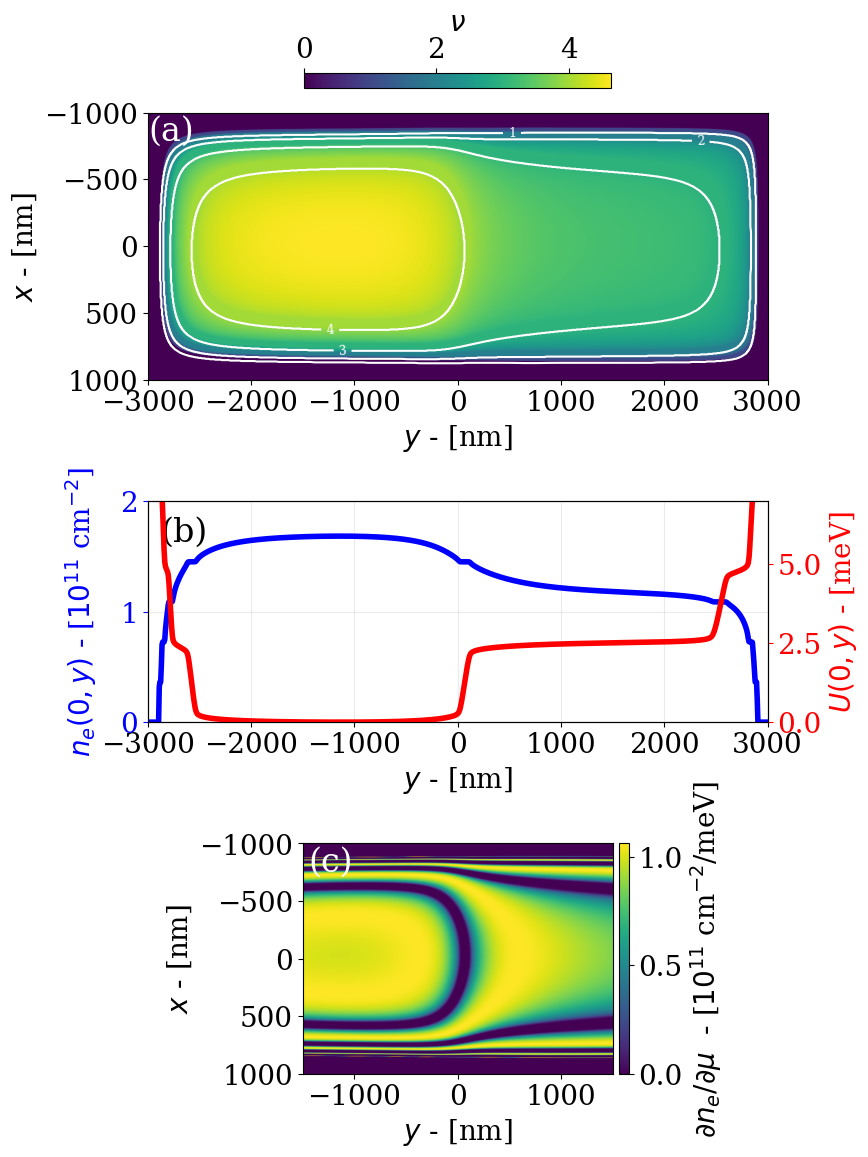

In [20]:
# ============================================================
# Combined 3-panel figure
#
# Numerical coordinates are unchanged.
# Only the displayed labels are swapped:
#   numerical x -> label "y"
#   numerical y -> label "x"
#
# (a) Local filling factor + integer isolines
# (b) Central cut: n_e(x=0,y) + U(x=0,y)
# (c) Compressibility, restricted to numerical x = ±1500 nm
# ============================================================

font = {
    'family': 'serif',
    'color': 'black',
    'weight': 'normal',
    'size': 20,
}

plt.rcParams['font.family'] = font['family']
plt.rcParams['font.size'] = font['size']
plt.rcParams['axes.labelsize'] = font['size']
plt.rcParams['xtick.labelsize'] = font['size']
plt.rcParams['ytick.labelsize'] = font['size']


# ------------------------------------------------------------
# Data
# ------------------------------------------------------------
x = res["x"]
y = np.flip(res["y"])
U = res["U"]
n = res["n"]
nu = res["nu"]
comp = res["compressibility"]

# Numerical y = 0 cut
# After relabeling, this corresponds to x = 0
iy = np.argmin(np.abs(y))


# ------------------------------------------------------------
# Figure layout
# ------------------------------------------------------------
fig = plt.figure(figsize=(8.0, 13))

gs = fig.add_gridspec(
    3, 12,
    height_ratios=[1.0, 0.72, 0.75],
    hspace=0.48,
    wspace=0.0,
)

# Panels (a) and (b): full width
ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, :])

# Panel (c): independently centered.
# Its position will NOT be affected by the colorbar.
ax3 = fig.add_subplot(gs[2, 3:9])


# ============================================================
# (a) Local filling factor
# ============================================================

im1 = ax1.imshow(
    nu,
    origin="lower",
    extent=[x.min(), x.max(), y.min(), y.max()],
    aspect="auto",
)

# Integer filling contours
nu_min = np.nanmin(nu)
nu_max = np.nanmax(nu)

integer_levels = np.arange(
    max(1, int(np.ceil(nu_min))),
    int(np.floor(nu_max)) + 1,
    1,
)

X, Y = np.meshgrid(x, y, indexing="xy")

cs1 = ax1.contour(
    X,
    Y,
    nu,
    levels=integer_levels,
    colors="white",
    linewidths=1.5,
)

ax1.clabel(
    cs1,
    inline=True,
    fontsize=9,
    fmt="%g",
)

# Only displayed coordinate labels are swapped
ax1.set_xlabel(r"$y$ - [nm]")
ax1.set_ylabel(r"$x$ - [nm]")


# Horizontal colorbar above panel (a)
cb1 = fig.colorbar(
    im1,
    ax=ax1,
    orientation="horizontal",
    location="top",
    pad=0.08,
    fraction=0.05,
)

cb1.set_label(r"$\nu$")


# ============================================================
# (b) Central cut
#
# LEFT  y-axis: electron density n_e(x=0,y)
# RIGHT y-axis: potential U(x=0,y)
#
# Numerically, U is shifted by its minimum before plotting.
# ============================================================

# ------------------------------------------------------------
# Electron density -- LEFT axis
# ------------------------------------------------------------
ax2.plot(
    x,
    n[iy, :] / 1e-3,
    color="blue",
    lw=4,
)

ax2.set_xlabel(r"$y$ - [nm]")

ax2.set_ylabel(
    r"$n_e(0,y)$ - [$10^{11}$ cm$^{-2}$]",
    color="blue",
    labelpad=15,
)

ax2.tick_params(
    axis="y",
    colors="blue",
)

ax2.grid(True, alpha=0.25)

# Same horizontal range as panel (a)
ax2.set_xlim(x.min(), x.max())
ax2.set_ylim(0, 2)


# ------------------------------------------------------------
# Potential -- RIGHT axis
# ------------------------------------------------------------
ax2r = ax2.twinx()

U_cut = U[iy, :]
U_cut_shifted = U_cut - np.nanmin(U_cut)

ax2r.plot(
    x,
    U_cut_shifted,
    color="red",
    lw=4,
)

ax2r.set_ylabel(
    r"$U(0,y)$ - [meV]",
    color="red",
)

ax2r.tick_params(
    axis="y",
    colors="red",
)

ax2r.set_ylim(0, 7)


# ============================================================
# (c) Compressibility
#     restricted to numerical x = ±1500 nm
# ============================================================

x_cut = 1500.0  # nm

mask_x = np.abs(x) <= x_cut

x_comp = x[mask_x]
comp_cut = comp[:, mask_x]

im3 = ax3.imshow(
    comp_cut / 1e-3,
    origin="lower",
    extent=[
        x_comp.min(),
        x_comp.max(),
        y.min(),
        y.max(),
    ],
    aspect="auto",
)

# Only displayed coordinate labels are swapped
ax3.set_xlabel(r"$y$ - [nm]")
ax3.set_ylabel(r"$x$ - [nm]")


# ============================================================
# Colorbar for panel (c)
#
# Created independently so that it does not shift ax3.
# ============================================================

# Get final position of panel (c) in figure coordinates
pos = ax3.get_position()

# These two parameters can now be adjusted independently
# without affecting the centering of panel (c)
cbar_gap = 0.008
cbar_width = 0.012

cax3 = fig.add_axes([
    pos.x1 + cbar_gap,   # left position
    pos.y0,              # bottom position
    cbar_width,          # width
    pos.height,          # height
])

cb3 = fig.colorbar(
    im3,
    cax=cax3,
    orientation="vertical",
)

cb3.set_label(
    r"$\partial n_e/\partial\mu$ "
    r" - [$10^{11}$ cm$^{-2}$/meV]"
)


# ============================================================
# Panel labels
# ============================================================

ax1.text(
    0.002, 0.99,
    "(a)",
    transform=ax1.transAxes,
    ha="left",
    va="top",
    color="white",
    fontsize=24,
)

ax2.text(
    0.02, 0.93,
    "(b)",
    transform=ax2.transAxes,
    ha="left",
    va="top",
    fontsize=24,
)

ax3.text(
    0.02, 0.99,
    "(c)",
    transform=ax3.transAxes,
    ha="left",
    va="top",
    color="white",
    fontsize=24,
)

ax1.invert_yaxis()
ax3.invert_yaxis()

plt.savefig(
    "fig5.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.12,
)
plt.show()

## Save simulation data and metadata

Run this cell after the simulation to save all relevant numerical arrays, parameters, and a small JSON summary. The most recent run is also recorded in `latest_simulation.json`, so a future run can resume from it.

In [13]:
from datetime import datetime


def save_simulation_2d(res, fig1, fig2, fig3, fig4, fig5, fig6, fig7, p: Params2D, results_dir=RESULTS_DIR, run_name=None, extra_metadata=None):
    results_dir = Path(results_dir)
    results_dir.mkdir(parents=True, exist_ok=True)

    if run_name is None:
        stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        run_name = f"sim_B_{p.B:.5g}_dist_{p.dist_fixed}_xedge_{p.x_gate_edge_nm}_{stamp}"

    run_dir = results_dir / run_name
    run_dir.mkdir(parents=True, exist_ok=False)

    data_path = run_dir / "data.npz"
    meta_path = run_dir / "metadata.json"

    # Numerical arrays. Kernels are included because they define the actual electrostatic problem used.
    arrays_to_save = {
        "x": res["x"],
        "y": res["y"],
        "X": res["X"],
        "Y": res["Y"],
        "mask": res["mask"],
        "n": res["n"],
        "nu": res["nu"],
        "U": res["U"],
        "U_ext": res["U_ext"],
        "compressibility": res["compressibility"],
        "n_donor_profile": res["n_donor_profile"],
        "top_gate_source_mask": res["top_gate_source_mask"],
        "K": res["K"],
        "K_ee_direct": res["K_ee_direct"],
        "K_ee_image": res["K_ee_image"],
        "K_donor_direct": res["K_donor_direct"],
        "K_donor_image": res["K_donor_image"],
        "history": res["history"],
    }
    np.savez_compressed(data_path, **arrays_to_save)

    summary = {
        "mu": json_safe_value(res["mu"]),
        "dist": json_safe_value(res["dist"]),
        "dx": json_safe_value(res["dx"]),
        "dy": json_safe_value(res["dy"]),
        "average_density": json_safe_value(average_density_2d(res["n"], res["mask"], res["dx"], res["dy"])),
        "target_density": json_safe_value(p.n_target),
        "center_filling": json_safe_value(res["nu"][p.Ny//2, p.Nx//2]),
        "nu_min": json_safe_value(np.nanmin(res["nu"])),
        "nu_max": json_safe_value(np.nanmax(res["nu"])),
        "converged_iterations_recorded": int(res["history"][-1, 0]) if len(res["history"]) else None,
        "final_dn": json_safe_value(res["history"][-1, 3]) if len(res["history"]) else None,
    }

    metadata = {
        "created_at": datetime.now().isoformat(timespec="seconds"),
        "params": params_to_json_dict(p),
        "summary": summary,
        "resumed_from": str(RESUMED_RUN_DIR) if RESUMED_RUN_DIR is not None else None,
        "parameter_overrides": {k: json_safe_value(v) for k, v in PARAMETER_OVERRIDES.items()},
    }
    if extra_metadata is not None:
        metadata["extra_metadata"] = extra_metadata

    with open(meta_path, "w") as f:
        json.dump(metadata, f, indent=2)

    latest_path = results_dir / "latest_simulation.json"
    with open(latest_path, "w") as f:
        json.dump({"run_dir": run_dir.name, "created_at": metadata["created_at"]}, f, indent=2)

    fig1.savefig(Path(run_dir) /"U_donor_half_top_gate.png", dpi=300)
    fig2.savefig(Path(run_dir) /"top_gate_source_mask.png", dpi=300)
    fig3.savefig(Path(run_dir) / "Effective_potential.png", dpi=300)
    fig4.savefig(Path(run_dir) / "Electron_density.png", dpi=300)
    fig5.savefig(Path(run_dir) / "Local_filling.png", dpi=300)
    fig6.savefig(Path(run_dir) / "Local_compressibility.png", dpi=300)
    fig7.savefig(Path(run_dir) / "Filling_cuts.png", dpi=300)

    print(f"Saved simulation to: {run_dir}")
    print(f"  data:     {data_path}")
    print(f"  metadata: {meta_path}")
    print(f"Updated latest pointer: {latest_path}")
    return run_dir


# Set SAVE_THIS_RUN = False if you do not want to save after testing.
SAVE_THIS_RUN = True

if SAVE_THIS_RUN:
    SAVED_RUN_DIR = save_simulation_2d(res, fig1, fig2, fig3, fig4, fig5, fig6, fig7, p)
else:
    SAVED_RUN_DIR = None
    print("SAVE_THIS_RUN is False; nothing saved.")

Saved simulation to: data_singlerun/sim_B_1.5_dist_200.0_xedge_4000.0_20260930_120012
  data:     data_singlerun/sim_B_1.5_dist_200.0_xedge_4000.0_20260930_120012/data.npz
  metadata: data_singlerun/sim_B_1.5_dist_200.0_xedge_4000.0_20260930_120012/metadata.json
Updated latest pointer: data_singlerun/latest_simulation.json


In [14]:
from modules.hartree_io import prepare_landau_context
ll = prepare_landau_context(p)

iy = len(y) // 2
ix = len(x) // 2
U = res["U"]
mu = res["mu"]

print("B =", p.B)
print("mu =", mu)
print("U center =", U[iy, ix])
print("Gamma =", ll["Gamma"])
print()
EB = ll["hbar_omega_c"]
for j, Ej in enumerate(ll["E"]):
    Eloc = U[iy, ix] + Ej
    delta = mu - Eloc

    arg = delta / (np.sqrt(2.0) * ll["Gamma"])
    occ = 0.5 * (1.0 + erf(arg))

    print(
        f"LL {j:2d}: "
        f"E={Ej/(EB)-.5: .6f}, "
        f"U+E={Eloc: .6f}, "
        f"mu-(U+E)={delta: .6f}, "
        f"occ={occ: .10f}"
    )

B = 1.5
mu = 19.27440165442528
U center = 8.294952843571402
Gamma = 0.13632901378650109

LL  0: E=-0.006329, U+E= 9.598244, mu-(U+E)= 9.676158, occ= 1.0000000000
LL  1: E= 0.968354, U+E= 12.171408, mu-(U+E)= 7.102993, occ= 1.0000000000
LL  2: E= 1.917721, U+E= 14.677738, mu-(U+E)= 4.596664, occ= 1.0000000000
LL  3: E= 2.841772, U+E= 17.117231, mu-(U+E)= 2.157171, occ= 1.0000000000
LL  4: E= 3.740506, U+E= 19.489889, mu-(U+E)=-0.215488, occ= 0.0569798337
LL  5: E= 4.613924, U+E= 21.795712, mu-(U+E)=-2.521310, occ= 0.0000000000


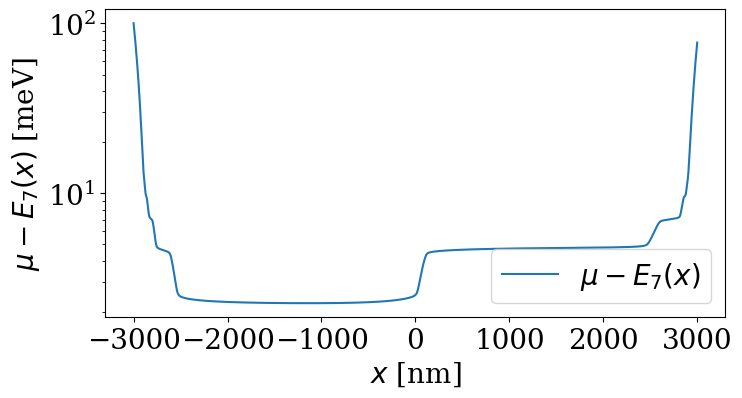

In [15]:
ll = prepare_landau_context(p)

# choose the same cut used in your LL plot
iy = len(y) // 2

n = 5
E_local = U[iy, :] + ll["E"][n]
delta = mu - E_local

occ = 0.5 * (
    1.0 + erf(
        delta / (np.sqrt(2.0) * ll["Gamma"])
    )
)

comp_norm = np.exp(
    -0.5 * (delta / ll["Gamma"])**2
)

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(x, abs(delta), label=r"$\mu-E_7(x)$")
ax.axhline(0, color="k", ls="--")
ax.set_yscale('log')
ax.set_xlabel(r"$x$ [nm]")
ax.set_ylabel(r"$\mu-E_7(x)$ [meV]")
ax.legend()

plt.show()